<a href="https://colab.research.google.com/github/kbletsa/Machine-Learning---Generative-Replay/blob/main/VAE_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Imports**

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, TensorDataset
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy

# **Configuration**

In [ ]:
BATCH_SIZE = 64
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
print("Κατέβασμα δεδομένων...")
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

Κατέβασμα δεδομένων...


# **Task Creation**

In [ ]:
def get_task_data(dataset, classes):
    targets = dataset.targets.numpy()
    mask = np.isin(targets, classes)
    indices = np.where(mask)[0]
    return Subset(dataset, indices)

tasks = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
train_loaders = []
test_loaders = []

for task_classes in tasks:
    task_train_subset = get_task_data(train_dataset, task_classes)
    task_test_subset = get_task_data(test_dataset, task_classes)
    train_loader = DataLoader(task_train_subset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(task_test_subset, batch_size=BATCH_SIZE, shuffle=False)
    train_loaders.append(train_loader)
    test_loaders.append(test_loader)

print("\n--- Έτοιμο το Split-MNIST! ---")
for i, loader in enumerate(train_loaders):
    print(f"Task {i+1} (Ψηφία {tasks[i]}): {len(loader.dataset)} εικόνες εκπαίδευσης")


--- Έτοιμο το Split-MNIST! ---
Task 1 (Ψηφία [0, 1]): 12665 εικόνες εκπαίδευσης
Task 2 (Ψηφία [2, 3]): 12089 εικόνες εκπαίδευσης
Task 3 (Ψηφία [4, 5]): 11263 εικόνες εκπαίδευσης
Task 4 (Ψηφία [6, 7]): 12183 εικόνες εκπαίδευσης
Task 5 (Ψηφία [8, 9]): 11800 εικόνες εκπαίδευσης


# **Naive Sequential Training**

## *Classifier Configuration*

In [ ]:
class SimpleClassifier(nn.Module):
    def __init__(self):
        super(SimpleClassifier, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Το μοντέλο θα τρέξει σε: {device}")

model = SimpleClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS_PER_TASK = 3

def evaluate_model(model, test_loaders, current_task_idx):
    model.eval()
    accuracies = []
    with torch.no_grad():
        for i in range(current_task_idx + 1):
            correct = 0
            total = 0
            for data, target in test_loaders[i]:
                data, target = data.to(device), target.to(device)
                outputs = model(data)
                _, predicted = torch.max(outputs.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
            acc = 100 * correct / total
            accuracies.append(acc)
    return accuracies

Το μοντέλο θα τρέξει σε: cuda


## *Training*

In [ ]:
print("\n--- Ξεκινάει η Εκπαίδευση (Naive Approach) ---")
for task_idx, train_loader in enumerate(train_loaders):
    print(f"\nΕκπαίδευση στο Task {task_idx + 1} (Ψηφία {tasks[task_idx]})...")
    model.train()

    for epoch in range(EPOCHS_PER_TASK):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()

    accs = evaluate_model(model, test_loaders, task_idx)
    print(f"Αποτελέσματα μετά το Task {task_idx + 1}:")
    for i, acc in enumerate(accs):
        print(f" -> Ακρίβεια στο Task {i + 1}: {acc:.2f}%")


--- Ξεκινάει η Εκπαίδευση (Naive Approach) ---

Εκπαίδευση στο Task 1 (Ψηφία [0, 1])...
Αποτελέσματα μετά το Task 1:
 -> Ακρίβεια στο Task 1: 99.86%

Εκπαίδευση στο Task 2 (Ψηφία [2, 3])...
Αποτελέσματα μετά το Task 2:
 -> Ακρίβεια στο Task 1: 0.00%
 -> Ακρίβεια στο Task 2: 98.14%

Εκπαίδευση στο Task 3 (Ψηφία [4, 5])...
Αποτελέσματα μετά το Task 3:
 -> Ακρίβεια στο Task 1: 0.00%
 -> Ακρίβεια στο Task 2: 0.00%
 -> Ακρίβεια στο Task 3: 99.20%

Εκπαίδευση στο Task 4 (Ψηφία [6, 7])...
Αποτελέσματα μετά το Task 4:
 -> Ακρίβεια στο Task 1: 0.00%
 -> Ακρίβεια στο Task 2: 0.00%
 -> Ακρίβεια στο Task 3: 0.00%
 -> Ακρίβεια στο Task 4: 99.80%

Εκπαίδευση στο Task 5 (Ψηφία [8, 9])...
Αποτελέσματα μετά το Task 5:
 -> Ακρίβεια στο Task 1: 0.00%
 -> Ακρίβεια στο Task 2: 0.00%
 -> Ακρίβεια στο Task 3: 0.00%
 -> Ακρίβεια στο Task 4: 0.00%
 -> Ακρίβεια στο Task 5: 98.29%


# **Random Replay Buffer**

## *Replay Buffer Configuration*

In [ ]:
class RandomReplayBuffer:
    def __init__(self, samples_per_task):
        self.samples_per_task = samples_per_task
        self.buffer_data = []
        self.buffer_targets = []

    def add_data(self, loader):
        all_data, all_targets = [], []
        for d, t in loader:
            all_data.append(d)
            all_targets.append(t)
        all_data = torch.cat(all_data)
        all_targets = torch.cat(all_targets)

        indices = torch.randperm(len(all_data))[:self.samples_per_task]
        self.buffer_data.append(all_data[indices])
        self.buffer_targets.append(all_targets[indices])

    def get_buffer_loader(self, batch_size):
        if len(self.buffer_data) == 0:
            return None
        b_data = torch.cat(self.buffer_data)
        b_targets = torch.cat(self.buffer_targets)
        dataset = TensorDataset(b_data, b_targets)
        return DataLoader(dataset, batch_size=batch_size, shuffle=True)

model_replay = SimpleClassifier().to(device)
optimizer_replay = optim.Adam(model_replay.parameters(), lr=0.001)

buffer = RandomReplayBuffer(samples_per_task=200)

## *Training*

In [ ]:
print("\n--- Ξεκινάει η Εκπαίδευση με Buffer Replay ---")
for task_idx, train_loader in enumerate(train_loaders):
    print(f"\nΕκπαίδευση στο Task {task_idx + 1} (Ψηφία {tasks[task_idx]})...")
    model_replay.train()

    buffer_loader = buffer.get_buffer_loader(BATCH_SIZE)
    if buffer_loader is not None:
        buffer_iter = iter(buffer_loader)

    for epoch in range(EPOCHS_PER_TASK):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            if buffer_loader is not None:
                try:
                    mem_data, mem_target = next(buffer_iter)
                except StopIteration:
                    buffer_iter = iter(buffer_loader)
                    mem_data, mem_target = next(buffer_iter)

                mem_data, mem_target = mem_data.to(device), mem_target.to(device)
                data = torch.cat([data, mem_data])
                target = torch.cat([target, mem_target])

            optimizer_replay.zero_grad()
            outputs = model_replay(data)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer_replay.step()

    buffer.add_data(train_loader)

    accs = evaluate_model(model_replay, test_loaders, task_idx)
    print(f"Αποτελέσματα μετά το Task {task_idx + 1}:")
    for i, acc in enumerate(accs):
        print(f" -> Ακρίβεια στο Task {i + 1}: {acc:.2f}%")


--- Ξεκινάει η Εκπαίδευση με Buffer Replay ---

Εκπαίδευση στο Task 1 (Ψηφία [0, 1])...
Αποτελέσματα μετά το Task 1:
 -> Ακρίβεια στο Task 1: 99.95%

Εκπαίδευση στο Task 2 (Ψηφία [2, 3])...
Αποτελέσματα μετά το Task 2:
 -> Ακρίβεια στο Task 1: 96.55%
 -> Ακρίβεια στο Task 2: 99.31%

Εκπαίδευση στο Task 3 (Ψηφία [4, 5])...
Αποτελέσματα μετά το Task 3:
 -> Ακρίβεια στο Task 1: 96.69%
 -> Ακρίβεια στο Task 2: 87.51%
 -> Ακρίβεια στο Task 3: 99.41%

Εκπαίδευση στο Task 4 (Ψηφία [6, 7])...
Αποτελέσματα μετά το Task 4:
 -> Ακρίβεια στο Task 1: 94.33%
 -> Ακρίβεια στο Task 2: 88.20%
 -> Ακρίβεια στο Task 3: 85.49%
 -> Ακρίβεια στο Task 4: 99.19%

Εκπαίδευση στο Task 5 (Ψηφία [8, 9])...
Αποτελέσματα μετά το Task 5:
 -> Ακρίβεια στο Task 1: 93.81%
 -> Ακρίβεια στο Task 2: 84.04%
 -> Ακρίβεια στο Task 3: 78.18%
 -> Ακρίβεια στο Task 4: 89.93%
 -> Ακρίβεια στο Task 5: 98.44%


# **Variational Autoencoder (VAE)**

## *VAE Configuration*

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()

        # --- ENCODER ---
        self.fc1 = nn.Linear(28 * 28, 400)
        self.fc21 = nn.Linear(400, latent_dim)
        self.fc22 = nn.Linear(400, latent_dim)

        # --- DECODER ---
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 28 * 28)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed_x = self.decode(z)
        return reconstructed_x, mu, logvar

def vae_loss_function(recon_x, x, mu, logvar):
    MSE = F.mse_loss(recon_x, x.view(-1, 784), reduction='sum')

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return MSE + KLD

latent_dim = 20
vae_model = VAE(latent_dim=latent_dim).to(device)
vae_optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)

print("Το VAE μοντέλο και η συνάρτηση σφάλματος δημιουργήθηκαν με επιτυχία!")

Το VAE μοντέλο και η συνάρτηση σφάλματος δημιουργήθηκαν με επιτυχία!


## *Task 1*

--- Εκπαίδευση VAE στο Task 1 (Ψηφία [0, 1]) ---
Εποχή: 1/10 	 Μέσο Σφάλμα (Loss): 226.6695
Εποχή: 2/10 	 Μέσο Σφάλμα (Loss): 137.4211
Εποχή: 3/10 	 Μέσο Σφάλμα (Loss): 123.6465
Εποχή: 4/10 	 Μέσο Σφάλμα (Loss): 116.5790
Εποχή: 5/10 	 Μέσο Σφάλμα (Loss): 112.5765
Εποχή: 6/10 	 Μέσο Σφάλμα (Loss): 109.9585
Εποχή: 7/10 	 Μέσο Σφάλμα (Loss): 107.7675
Εποχή: 8/10 	 Μέσο Σφάλμα (Loss): 106.0521
Εποχή: 9/10 	 Μέσο Σφάλμα (Loss): 104.7553
Εποχή: 10/10 	 Μέσο Σφάλμα (Loss): 103.7442

Η εκπαίδευση ολοκληρώθηκε! Πάμε να φτιάξουμε συνθετικές εικόνες...


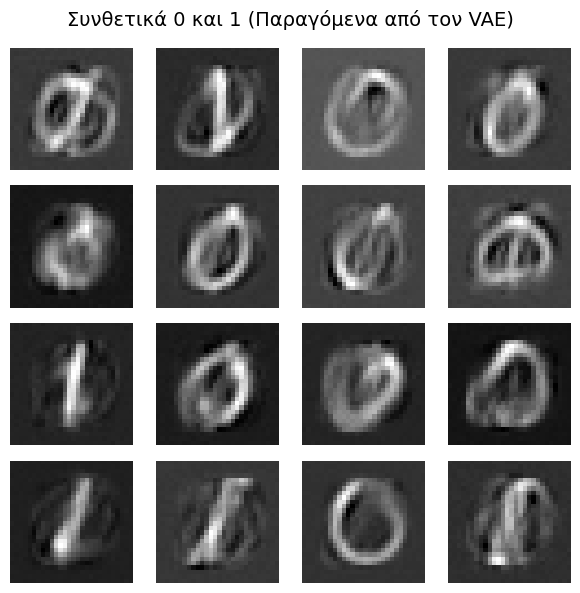

In [ ]:
VAE_EPOCHS = 10

print(f"--- Εκπαίδευση VAE στο Task 1 (Ψηφία {tasks[0]}) ---")
vae_model.train()

for epoch in range(VAE_EPOCHS):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loaders[0]):
        data = data.to(device)
        vae_optimizer.zero_grad()
        recon_batch, mu, logvar = vae_model(data)
        loss = vae_loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        vae_optimizer.step()

    avg_loss = train_loss / len(train_loaders[0].dataset)
    print(f'Εποχή: {epoch+1}/{VAE_EPOCHS} \t Μέσο Σφάλμα (Loss): {avg_loss:.4f}')

print("\nΗ εκπαίδευση ολοκληρώθηκε! Πάμε να φτιάξουμε συνθετικές εικόνες...")

vae_model.eval()
with torch.no_grad():
    sample_noise = torch.randn(16, latent_dim).to(device)
    generated_images = vae_model.decode(sample_noise).cpu()

generated_images = generated_images.view(16, 28, 28)

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
fig.suptitle('Συνθετικά 0 και 1 (Παραγόμενα από τον VAE)', fontsize=14)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_images[i].numpy(), cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

# **Final Experiment**

In [ ]:
gr_classifier = SimpleClassifier().to(device)
gr_vae = VAE(latent_dim=20).to(device)

opt_classifier = optim.Adam(gr_classifier.parameters(), lr=0.001)
opt_vae = optim.Adam(gr_vae.parameters(), lr=0.001)

prev_classifier = None
prev_vae = None

print("\n--- Ξεκινάει η Εκπαίδευση με GENERATIVE REPLAY ---")

for task_idx, train_loader in enumerate(train_loaders):
    print(f"\nΕκπαίδευση στο Task {task_idx + 1} (Ψηφία {tasks[task_idx]})...")
    gr_classifier.train()
    gr_vae.train()

    for epoch in range(EPOCHS_PER_TASK):
        for real_data, real_target in train_loader:
            real_data, real_target = real_data.to(device), real_target.to(device)

            # --- GENERATIVE REPLAY LOGIC ---
            if prev_vae is not None and prev_classifier is not None:
                # 1. Ζητάμε από τον προηγούμενο VAE να φτιάξει συνθετικές εικόνες (ίδιος αριθμός με το batch)
                with torch.no_grad():
                    z = torch.randn(real_data.size(0), latent_dim).to(device)
                    fake_data = prev_vae.decode(z).view(-1, 1, 28, 28)

                    # 2. Ζητάμε από τον προηγούμενο Classifier να τους βάλει ετικέτες (labels)
                    fake_outputs = prev_classifier(fake_data)
                    _, fake_target = torch.max(fake_outputs.data, 1)

                # 3. Ενώνουμε τα Πραγματικά (Νέο Task) με τα Συνθετικά (Παλιά Tasks)
                combined_data = torch.cat([real_data, fake_data])
                combined_target = torch.cat([real_target, fake_target])
            else:
                # Στο Task 1 δεν έχουμε προηγούμενα δεδομένα
                combined_data = real_data
                combined_target = real_target

            # --- ΕΚΠΑΙΔΕΥΣΗ CLASSIFIER ---
            opt_classifier.zero_grad()
            outputs = gr_classifier(combined_data)
            loss_class = criterion(outputs, combined_target)
            loss_class.backward()
            opt_classifier.step()

            # --- ΕΚΠΑΙΔΕΥΣΗ VAE (Κάνει κι αυτός Continual Learning!) ---
            opt_vae.zero_grad()
            recon_batch, mu, logvar = gr_vae(combined_data)
            loss_vae = vae_loss_function(recon_batch, combined_data, mu, logvar)
            loss_vae.backward()
            opt_vae.step()

    accs = evaluate_model(gr_classifier, test_loaders, task_idx)
    print(f"Αποτελέσματα μετά το Task {task_idx + 1}:")
    for i, acc in enumerate(accs):
        print(f" -> Ακρίβεια στο Task {i + 1}: {acc:.2f}%")

    prev_classifier = copy.deepcopy(gr_classifier)
    prev_classifier.eval()
    prev_vae = copy.deepcopy(gr_vae)
    prev_vae.eval()


--- Ξεκινάει η Εκπαίδευση με GENERATIVE REPLAY ---

Εκπαίδευση στο Task 1 (Ψηφία [0, 1])...
Αποτελέσματα μετά το Task 1:
 -> Ακρίβεια στο Task 1: 99.91%

Εκπαίδευση στο Task 2 (Ψηφία [2, 3])...
Αποτελέσματα μετά το Task 2:
 -> Ακρίβεια στο Task 1: 95.32%
 -> Ακρίβεια στο Task 2: 98.78%

Εκπαίδευση στο Task 3 (Ψηφία [4, 5])...
Αποτελέσματα μετά το Task 3:
 -> Ακρίβεια στο Task 1: 80.33%
 -> Ακρίβεια στο Task 2: 88.00%
 -> Ακρίβεια στο Task 3: 98.93%

Εκπαίδευση στο Task 4 (Ψηφία [6, 7])...
Αποτελέσματα μετά το Task 4:
 -> Ακρίβεια στο Task 1: 63.45%
 -> Ακρίβεια στο Task 2: 85.60%
 -> Ακρίβεια στο Task 3: 95.04%
 -> Ακρίβεια στο Task 4: 98.09%

Εκπαίδευση στο Task 5 (Ψηφία [8, 9])...
Αποτελέσματα μετά το Task 5:
 -> Ακρίβεια στο Task 1: 24.92%
 -> Ακρίβεια στο Task 2: 68.36%
 -> Ακρίβεια στο Task 3: 59.28%
 -> Ακρίβεια στο Task 4: 91.39%
 -> Ακρίβεια στο Task 5: 96.97%
